In [82]:
import zipfile
with zipfile.ZipFile('civic_dataset.zip', 'r') as z:
    z.extractall('.')
print('Dataset extracted ✓')


FileNotFoundError: [Errno 2] No such file or directory: 'civic_dataset.zip'

In [83]:
import subprocess
subprocess.run(['pip', 'install', 'timm', '-q'], check=True)


CompletedProcess(args=['pip', 'install', 'timm', '-q'], returncode=0)

In [84]:
import subprocess
subprocess.run(['nvidia-smi'], check=False)

import torch
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"GPU name       : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")


CUDA available : True
GPU name       : Tesla T4


In [44]:
import subprocess
subprocess.run(['pip', 'install', 'timm', '-q'], check=True)


CompletedProcess(args=['pip', 'install', 'timm', '-q'], returncode=0)

In [85]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from torchvision import datasets, transforms
import timm
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")



Using device: cuda


In [86]:
# Hyperparameters

BATCH_SIZE        = 32
EPOCHS            = 20          # increased from 15 — unknown class needs more epochs
LR                = 3e-4
WEIGHT_DECAY      = 1e-4
IMAGE_SIZE        = 224

# Inference safety knobs (no retraining needed to tune these)
TEMPERATURE       = 0.43         # >1 softens overconfident softmax — try 1.5–3.0
CONF_THRESHOLD    = 0.65        # below this → reject as "not a civic issue"
ENERGY_THRESHOLD  = -7.5        # more negative = confident in-distribution
                                # calibrate by printing energy scores on val set

NUM_CLASSES       = 4           # ← was 3 in v1, now 4 (includes "unknown")



In [87]:
# Data Transforms

# Training: augmentation helps generalise, especially for unknown class
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),           # useful for dump/pothole images
    transforms.RandomRotation(15),                   # slightly wider than v1's 10
    transforms.ColorJitter(brightness=0.3,
                           contrast=0.3,
                           saturation=0.3,
                           hue=0.05),
    transforms.RandomGrayscale(p=0.05),              # helps with varied lighting
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]) # ImageNet stats — required for pretrained weights
])

# Validation: NO augmentation — we want a clean, unbiased measurement
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])


In [88]:
train_ds = datasets.ImageFolder('civic_dataset/train/', transform=train_transform)
val_ds   = datasets.ImageFolder('civic_dataset/val/',   transform=val_transform)

print(f"\nClass → Index mapping : {train_ds.class_to_idx}")
print(f"Train samples         : {len(train_ds)}")
print(f"Val   samples         : {len(val_ds)}")

# Print per-class counts so you can spot imbalance immediately
train_counts = np.bincount(train_ds.targets)
val_counts   = np.bincount(val_ds.targets)
for i, cls in enumerate(train_ds.classes):
    print(f"  {cls:<30} train={train_counts[i]:>4}   val={val_counts[i]:>4}")



Class → Index mapping : {'electricity_wire_issue': 0, 'garbage_dump': 1, 'road_pothole': 2, 'unknown': 3}
Train samples         : 1650
Val   samples         : 524
  electricity_wire_issue         train= 280   val=  49
  garbage_dump                   train= 579   val= 138
  road_pothole                   train= 291   val=  73
  unknown                        train= 500   val= 264


In [89]:
# compute_class_weight('balanced') = total_samples / (n_classes * class_count)
# This gives natural inverse-frequency weights.
raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_ds.targets),
    y=train_ds.targets
)

clipped_weights = np.clip(raw_weights, a_min=0.5, a_max=3.0)

# Re-normalise so the mean weight stays at 1.0 (keeps learning rate sane)
clipped_weights = clipped_weights / clipped_weights.mean()

class_weights = torch.tensor(clipped_weights, dtype=torch.float).to(device)
print(f"\nClass weights (raw)    : {np.round(raw_weights,   3)}")
print(f"Class weights (final)  : {class_weights.cpu().numpy().round(3)}")




Class weights (raw)    : [1.473 0.712 1.418 0.825]
Class weights (final)  : [1.331 0.644 1.28  0.745]


In [90]:
# Each sample's draw probability is inversely proportional to its class frequency.
# This means minority classes (e.g. electricity_wire) appear just as often
# in every batch as the majority class (garbage_dump).
sample_weights = 1.0 / train_counts[train_ds.targets]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True   # replacement=True is correct and required here
)


In [91]:
# dataloaders

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,      # use sampler, NOT shuffle=True (they are mutually exclusive)
    num_workers=2,        # Colab has 2 CPU cores; bump to 4 if on Colab Pro
    pin_memory=True       # speeds up CPU→GPU transfer
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,        # always False for val — order must be deterministic
    num_workers=2,
    pin_memory=True
)

# Quick sanity check — make sure one batch loads without errors
imgs, labels = next(iter(train_loader))
print(f"\n✅ Batch shape : {imgs.shape}  (expected [32, 3, 224, 224])")
print(f"Label sample  : {labels[:8].tolist()}")



✅ Batch shape : torch.Size([32, 3, 224, 224])  (expected [32, 3, 224, 224])
Label sample  : [1, 2, 0, 3, 0, 3, 2, 0]


In [92]:
model = timm.create_model(
    'mobilenetv3_small_100',
    pretrained=True,
    num_classes=NUM_CLASSES   # 4-way head now (was 3 in v1)
).to(device)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    model.classifier
)
model = model.to(device)

# Confirm output shape
with torch.no_grad():
    dummy = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    out   = model(dummy)
    print(f"\nModel output shape : {out.shape}  (expected [1, {NUM_CLASSES}])")



Model output shape : torch.Size([1, 4])  (expected [1, 4])


In [93]:
# LOSS, OPTIMIZER, SCHEDULER

# CrossEntropyLoss with class weights — penalises misclassifying
# rare classes more heavily than common ones.
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
# label_smoothing=0.05 prevents the model from becoming too "sharp"
# about its predictions — slightly reduces overconfidence.

# AdamW: like Adam but weight decay is decoupled (better regularisation)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# Cosine annealing: starts at LR, smoothly decays to near-zero.
# Better than step decay for fine-tuning pretrained models.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6     # floor LR so training doesn't die completely
)

# GradScaler for mixed precision (float16 on GPU → 2× faster, same accuracy)
scaler = torch.amp.GradScaler('cuda')

In [94]:
import numpy as np
import torch
import torch.nn as nn

def mixup_batch(imgs, labels, alpha=0.3):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(imgs.size(0))
    mixed = lam * imgs + (1 - lam) * imgs[idx]
    return mixed, labels, labels[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


def train_epoch(model, loader, criterion, optimizer, device, scaler):
    """Run one full pass over the training set. Returns (loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)  # slightly faster than zero_grad()

        with torch.amp.autocast(device_type='cuda'):
            mixed_imgs, la, lb, lam = mixup_batch(imgs, labels)
            outputs = model(mixed_imgs)
            loss    = mixup_criterion(criterion, outputs, la, lb, lam)

        # Scale the loss and perform backward pass
        scaler.scale(loss).backward()

        # Gradient clipping — prevents exploding gradients, stabilises training
        # This was missing in v1 and can cause NaN loss spikes.
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), correct / total


def val_epoch(model, loader, criterion, device):
    """Run one full pass over the validation set. Returns (loss, acc, preds, labels)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            outputs = model(imgs)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels

In [95]:
# TRAINING LOOP

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_score = None
        self.counter    = 0
        self.stop       = False

    def __call__(self, val_loss):
        if self.best_score is None or val_loss < self.best_score - self.min_delta:
            self.best_score = val_loss
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
early_stop = EarlyStopping(patience=5)
best_val_acc = 0.0
early_stop = EarlyStopping(patience=5)
train_accs, val_accs, train_losses, val_losses = [], [], [], []

print(f"\n{'─'*65}")
print(f"{'Epoch':>6} {'Train Loss':>11} {'Train Acc':>10} {'Val Loss':>10} {'Val Acc':>10} {'Best':>8}")
print(f"{'─'*65}")

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device, scaler)
    vl_loss, vl_acc, preds, labels_val = val_epoch(model, val_loader, criterion, device)
    scheduler.step()

    train_accs.append(tr_acc);   val_accs.append(vl_acc)
    train_losses.append(tr_loss); val_losses.append(vl_loss)

    is_best = vl_acc > best_val_acc
    if is_best:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), '/content/best_civic_classifier_v2.pth')

    print(f"  {epoch+1:>4}   {tr_loss:>10.4f}   {tr_acc:>9.1%}   {vl_loss:>9.4f}   {vl_acc:>9.1%}   {'★' if is_best else ''}")

    early_stop(vl_loss)
    if early_stop.stop:
          print(f"\n⏹ Early stopping triggered at epoch {epoch+1}")
          break

print(f"{'─'*65}")
print(f"\n✅ Best Val Accuracy: {best_val_acc:.1%}")


─────────────────────────────────────────────────────────────────
 Epoch  Train Loss  Train Acc   Val Loss    Val Acc     Best
─────────────────────────────────────────────────────────────────
     1       2.8239       40.4%      2.6168       40.5%   ★
     2       1.4988       47.9%      1.0281       73.9%   ★
     3       1.2335       47.4%      1.1962       60.7%   
     4       1.2170       47.9%      1.0367       69.5%   
     5       0.9309       51.1%      0.6183       84.9%   ★
     6       0.9018       52.4%      0.9629       68.7%   
     7       0.8472       57.0%      0.6062       85.1%   ★
     8       0.7562       53.0%      0.6166       84.4%   
     9       0.8822       48.2%      0.5909       84.4%   
    10       0.7642       51.8%      0.5180       87.4%   ★
    11       0.7821       56.1%      0.5277       88.5%   ★
    12       0.6751       61.5%      0.6541       81.7%   
    13       0.5685       54.9%      0.5894       83.8%   
    14       0.6583       56.9%  

In [96]:
# ─────────────────────────────────────────────────────────────────────
# SECTION 14 ▸ FINAL EVALUATION
# ─────────────────────────────────────────────────────────────────────

# Re-initialize the model with the correct architecture before loading the state dict
model = timm.create_model(
    'mobilenetv3_small_100',
    pretrained=True,
    num_classes=NUM_CLASSES
).to(device)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    model.classifier
)
model = model.to(device)

# Load the checkpoint that had the best val accuracy
model.load_state_dict(torch.load('/content/best_civic_classifier_v2.pth'))

# Run one final val pass to get clean predictions
_, _, preds_final, labels_final = val_epoch(model, val_loader, criterion, device)

print("\n📊 Final Classification Report:")
print(classification_report(
    labels_final,
    preds_final,
    target_names=train_ds.classes,
    digits=4
))


📊 Final Classification Report:
                        precision    recall  f1-score   support

electricity_wire_issue     0.8545    0.9592    0.9038        49
          garbage_dump     0.9130    0.9130    0.9130       138
          road_pothole     0.7717    0.9726    0.8606        73
               unknown     0.9874    0.8939    0.9384       264

              accuracy                         0.9160       524
             macro avg     0.8817    0.9347    0.9040       524
          weighted avg     0.9254    0.9160    0.9176       524



In [97]:
#  CALIBRATE OOD THRESHOLDS ON VAL SET

model.eval()
all_confidences = []
all_energies    = []

with torch.no_grad():
    for imgs, _ in val_loader:
        imgs    = imgs.to(device)
        logits  = model(imgs)

        # Temperature-scaled softmax confidence
        probs   = torch.softmax(logits / TEMPERATURE, dim=1)
        confs   = probs.max(dim=1).values
        all_confidences.extend(confs.cpu().numpy())

        # Energy score: lower (more negative) = more in-distribution
        energy  = -TEMPERATURE * torch.logsumexp(logits / TEMPERATURE, dim=1)
        all_energies.extend(energy.cpu().numpy())

p5_conf   = np.percentile(all_confidences, 5)
p5_energy = np.percentile(all_energies, 95)   # 95th pct = worst in-dist energy

print(f"\n📐 Calibration on val set:")
print(f"  Confidence — mean={np.mean(all_confidences):.3f}  "
      f"5th pct={p5_conf:.3f}  → set CONF_THRESHOLD ≈ {p5_conf:.2f}")
print(f"  Energy     — mean={np.mean(all_energies):.3f}  "
      f"95th pct={p5_energy:.3f}  → set ENERGY_THRESHOLD ≈ {p5_energy:.2f}")





📐 Calibration on val set:
  Confidence — mean=0.963  5th pct=0.721  → set CONF_THRESHOLD ≈ 0.72
  Energy     — mean=-3.384  95th pct=-1.717  → set ENERGY_THRESHOLD ≈ -1.72

  Update TEMPERATURE/CONF_THRESHOLD/ENERGY_THRESHOLD at the top of this
  script and in your FastAPI inference function accordingly.


In [98]:
# Define this OUTSIDE the function (module-level constant)
CLASS_THRESHOLDS = {
    'electricity_wire_issue': 0.65,
    'garbage_dump':           0.65,
    'road_pothole':           0.80,
    'unknown':                0.65,
}

def predict(
    model,
    image_tensor: torch.Tensor,
    class_names: list,
    device,
    temperature:      float = TEMPERATURE,
    energy_threshold: float = ENERGY_THRESHOLD,   # ← was missing entirely
) -> dict:
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0).to(device)
        logits = model(image_tensor)

        # Guard 1: Energy Score
        energy = (-temperature * torch.logsumexp(logits / temperature, dim=1)).item()
        if energy > energy_threshold:
            return {
                "status"          : "rejected",
                "predicted_class" : "not_a_civic_issue",
                "confidence"      : None,
                "reason"          : f"Energy score {energy:.2f} > threshold {energy_threshold} — OOD image",
                "probs"           : None,
            }

        # Softmax with temperature scaling
        probs = torch.softmax(logits / temperature, dim=1).squeeze()
        confidence, predicted_idx = probs.max(0)
        confidence   = confidence.item()
        class_name   = class_names[predicted_idx]

        # Guard 2: Per-class confidence threshold  ← fixed
        threshold = CLASS_THRESHOLDS.get(class_name, 0.65)
        if confidence < threshold:
            return {
                "status"          : "rejected",
                "predicted_class" : "not_a_civic_issue",
                "confidence"      : round(confidence, 4),
                "reason"          : f"Confidence {confidence:.2%} < threshold {threshold:.0%} for class '{class_name}'",
                "probs"           : {cn: round(probs[i].item(), 6) for i, cn in enumerate(class_names)},
            }

        return {
            "status"          : "classified",
            "predicted_class" : class_name,
            "confidence"      : round(confidence, 4),
            "reason"          : None,
            "probs"           : {cn: round(probs[i].item(), 6) for i, cn in enumerate(class_names)},
        }

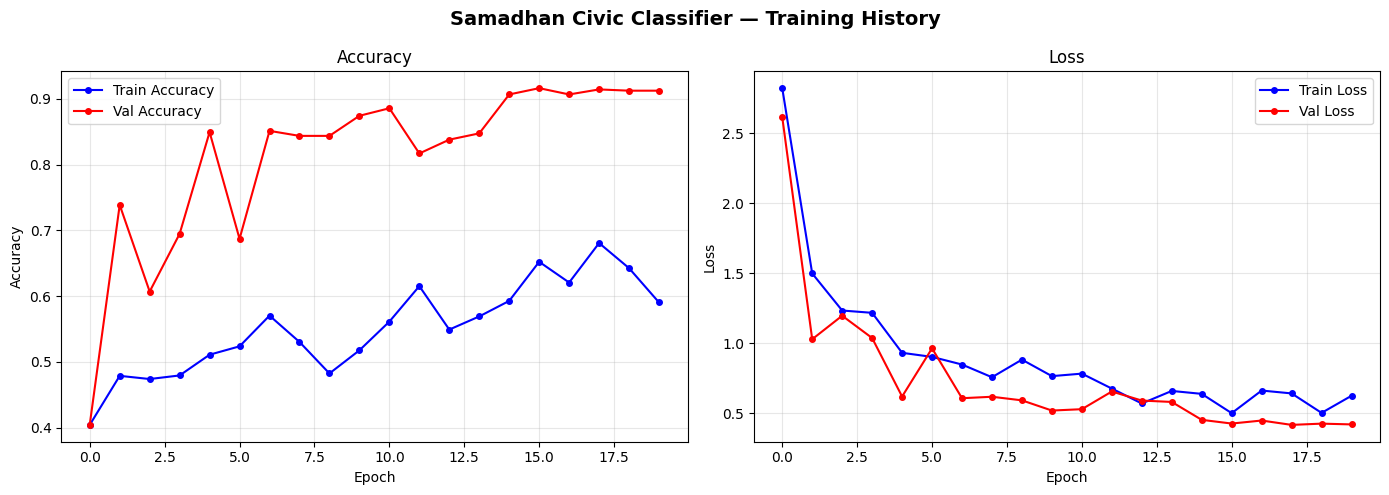

In [99]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Samadhan Civic Classifier — Training History', fontsize=14, fontweight='bold')

ax1.plot(train_accs, 'b-o', markersize=4, label='Train Accuracy')
ax1.plot(val_accs,   'r-o', markersize=4, label='Val Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(train_losses, 'b-o', markersize=4, label='Train Loss')
ax2.plot(val_losses,   'r-o', markersize=4, label='Val Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.set_title('Loss'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [100]:
traced = torch.jit.script(model)
traced.save('/content/civic_classifier_v2.pt')

print("\n✅ Saved files:")
print("   /content/best_civic_classifier_v2.pth  — raw weights (for further fine-tuning)")
print("   /content/civic_classifier_v2.pt         — TorchScript (for FastAPI deployment)")
print("   /content/training_curves.png            — accuracy + loss ")


✅ Saved files:
   /content/best_civic_classifier_v2.pth  — raw weights (for further fine-tuning)
   /content/civic_classifier_v2.pt         — TorchScript (for FastAPI deployment)
   /content/training_curves.png            — accuracy + loss 


In [101]:
model.eval()
all_energies = []

with torch.no_grad():
    for imgs, _ in val_loader:
        imgs   = imgs.to(device)
        logits = model(imgs)
        energy = -TEMPERATURE * torch.logsumexp(logits / TEMPERATURE, dim=1)
        all_energies.extend(energy.cpu().numpy())

import numpy as np
print(f"Energy mean  : {np.mean(all_energies):.2f}")
print(f"Energy 95th% : {np.percentile(all_energies, 95):.2f}")
print(f"Set ENERGY_THRESHOLD to: {np.percentile(all_energies, 95):.2f}")

Energy mean  : -3.38
Energy 95th% : -1.72
Set ENERGY_THRESHOLD to: -1.72
